# pyINSPECTA demo

In [1]:
from __future__ import annotations

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.dpi"] = 150

from pyINSPECTA import SDHDF
from pyINSPECTA.logger import logger

logger.setLevel("INFO")

#### Let's load an SDHDF file - it is represented by an SDHDF class instance:

In [2]:
# SDHDF v1.9.3 (NOTE: This file has a single integration only)
fname = "./test_data/sdhdf_v1.9.3.hdf"
#
# SDHDF v2.0
# fname = "./test_data/sdhdf_v2.0.hdf"
#
# SDHDF v2.1
# fname = "./test_data/sdhdf_v2.1.hdf"
#
# SDHDF v2.2
# fname = "./test_data/sdhdf_v2.2.hdf"
#
# SDHDF v3.0
# fname = "./test_data/sdhdf_v3.0.hdf"
#
# SDHDF v4.0 (NOTE: this version onwards has compound attributes)
# fname = "./test_data/sdhdf_v4.0.hdf"
#

In [3]:
sdhdf = SDHDF(fname, parallel=True)

pyINSPECTA - INFO: Dask dashboard at: http://127.0.0.1:8787/status
pyINSPECTA - INFO: SDHDF version: 2.0
pyINSPECTA - WARNING: Path '/beam_0/metadata/cal_band_params' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/astronomy_data/data_weights' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/astronomy_data/data_flags' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal32_data' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal_data_on' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal_data_off' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal_data_weights' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal_data_flags' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/calibrator_data/cal_frequency' not found in file
pyINSPECTA - WARNING: Path '/beam_0/band_SB0/metadata/cal_obs_params' n

#### The SDHDF class instance contains information on the beams...

In [4]:
sdhdf.beams[0]

Beam(label='beam_0', filename='./test_data/sdhdf_v1.9.3.hdf', definition={'version': '2.0', 'beam': {'attributes': {'DESCRIPTION': 'SDHDF group containing data products specific to the antenna beam', 'NAME': 'beam', 'SDHDF_CLASS': 'sdhdf_beam'}, 'metadata': {'attributes': {'DESCRIPTION': 'SDHDF group containing observation metadata', 'NAME': 'metadata', 'SDHDF_CLASS': 'sdhdf_meta'}, 'band_params': 'metadata/band_params', 'cal_band_params': 'metadata/cal_band_params'}, 'band': {'attributes': {'DESCRIPTION': 'SDHDF group containing data products specific to the frequency band', 'NAME': 'band', 'SDHDF_CLASS': 'sdhdf_band'}, 'astronomy': {'data': 'astronomy_data/data', 'weights': 'astronomy_data/data_weights', 'flags': 'astronomy_data/data_flags', 'frequency': 'astronomy_data/frequency'}, 'calibrator': {'cal_binned': 'calibrator_data/cal32_data', 'cal_on': 'calibrator_data/cal_data_on', 'cal_off': 'calibrator_data/cal_data_off', 'weights': 'calibrator_data/cal_data_weights', 'flags': 'cali

#### ...and all associated metadata:

In [5]:
sdhdf.metadata

MetaData(filename='./test_data/sdhdf_v1.9.3.hdf')

#### Let's explore the observation metadata - for example the primary_header dataset can be displayed with:

In [6]:
sdhdf.metadata.primary_header

,DATE,HDR_DEFN,HDR_DEFN_VERSION,FILE_FORMAT,FILE_FORMAT_VERSION,SCHED_BLOCK_ID,CAL_MODE,INSTRUMENT,OBSERVER,OBS_TYPE,PID,RECEIVER,TELESCOPE,UTC_START,N_BEAMS
0,2021-04-08-04:57:40,SDHDF,1.9.3,HDF,5.0,25494,OFF,Medusa,kac014,ScanContinuum,P1117,UWL,Parkes,2021-04-07-18:49:04,1


#### The attribute keys and descriptions can be acccessed with:

In [7]:
sdhdf.metadata.primary_header.attrs.keys()

dict_keys(['CAL_MODE', 'DATE', 'DESCRIPTION', 'FILE_FORMAT', 'FILE_FORMAT_VERSION', 'HDR_DEFN', 'HDR_DEFN_VERSION', 'INSTRUMENT', 'NAME', 'N_BEAMS', 'OBSERVER', 'OBS_TYPE', 'PID', 'RECEIVER', 'SCHED_BLOCK_ID', 'SDHDF_CLASS', 'TELESCOPE', 'UTC_START'])

In [8]:
sdhdf.metadata.primary_header.attrs.values()

dict_values(['Calibration mode (ON | OFF)', 'File creation date (UTC YYYY-MM-DD-hh:mm:ss)', 'General observation metadata', 'File format', 'File format version', 'File format definition', 'File format definition version', 'Backend instrument name', 'primary_header', 'Number of beams', 'Observer name', 'Observation type (TRACK | SCAN)', 'Project ID', 'Receiver name', 'Schedule block ID', 'sdhdf_table', 'Telescope name', 'Observation start (UTC YYYY-MM-DD-hh:mm:ss)'])

#### The attribute values, for example for the key 'TELESCOPE', can be accessed from the table:

In [9]:
sdhdf.metadata.primary_header.table["TELESCOPE"][0]

'Parkes'

#### The same applies for accessing the observation parameters with for example:

In [10]:
sdhdf.metadata.obs_params

,ELAPSED_TIME,TIME_DB,MJD,UTC,UT_DATE,AEST,RA_STR,DEC_STR,RA_DEG,DEC_DEG,...,RA_OFFSET,DEC_OFFSET,AZ_OFFSET,EL_OFFSET,AZ_DRIVE_RATE,ZE_DRIVE_RATE,HOUR_ANGLE,PARA_ANGLE,WIND_DIR,WIND_SPD
0,0.492,2021-04-07T18:49:04.49Z,59311.78408,18:49:04.49,2021-04-07,04:49:05.39,19:30:21.47,-63:42:45.01,292.5895,-63.7125,...,0.0,0.0,0.0,0.0,0.3949,0.1966,333.7163,-40.7,4.0,124.0


#### The Beam class contains the subband data - these can be accessed in a similar way to the beams:

In [11]:
sdhdf.beams[0].subbands

[SubBand(label='band_SB0', filename='./test_data/sdhdf_v1.9.3.hdf', definition={'version': '2.0', 'beam': {'attributes': {'DESCRIPTION': 'SDHDF group containing data products specific to the antenna beam', 'NAME': 'beam', 'SDHDF_CLASS': 'sdhdf_beam'}, 'metadata': {'attributes': {'DESCRIPTION': 'SDHDF group containing observation metadata', 'NAME': 'metadata', 'SDHDF_CLASS': 'sdhdf_meta'}, 'band_params': 'metadata/band_params', 'cal_band_params': 'metadata/cal_band_params'}, 'band': {'attributes': {'DESCRIPTION': 'SDHDF group containing data products specific to the frequency band', 'NAME': 'band', 'SDHDF_CLASS': 'sdhdf_band'}, 'astronomy': {'data': 'astronomy_data/data', 'weights': 'astronomy_data/data_weights', 'flags': 'astronomy_data/data_flags', 'frequency': 'astronomy_data/frequency'}, 'calibrator': {'cal_binned': 'calibrator_data/cal32_data', 'cal_on': 'calibrator_data/cal_data_on', 'cal_off': 'calibrator_data/cal_data_off', 'weights': 'calibrator_data/cal_data_weights', 'flags':

#### The data are stored as either an `xarray.Dataset` or `pandas.DataFrame` depending on the data type:

In [12]:
sdhdf.beams[0].subbands[0].astronomy_dataset

<xarray.Dataset>
Dimensions:        (time: 1, frequency: 256, polarization: 4, bin: 1, meta: 25)
Coordinates: (12/28)
    ELAPSED_TIME   (time) float64 0.492
    TIME_DB        (time) object '2021-04-07T18:49:04.49Z'
    MJD            (time) float64 5.931e+04
    UTC            (time) object '18:49:04.49'
    UT_DATE        (time) object '2021-04-07'
    AEST           (time) object '04:49:05.39'
    ...             ...
    PARA_ANGLE     (time) float64 -40.7
    WIND_DIR       (time) float64 4.0
    WIND_SPD       (time) float64 124.0
  * frequency      (frequency) float32 719.6 719.6 719.6 ... 719.7 719.7 719.7
  * time           (time) int64 0
  * meta           (meta) object 'ELAPSED_TIME' 'TIME_DB' ... 'WIND_SPD'
Dimensions without coordinates: polarization, bin
Data variables:
    data           (time, polarization, frequency, bin) float32 dask.array<chunksize=(1, 4, 256, 1), meta=np.ndarray>
    flag           (polarization, frequency) float32 dask.array<chunksize=(4, 256), meta=np.ndarray>
    metadata       (time, meta) object 0.49200000000000005 ... 124.0

In [13]:
sdhdf.metadata.frequency.table

,0,1,2,3,4,5,6
0,CLASS,DESCRIPTION,FRAME,NAME,REFERENCE_LIST,SDHDF_CLASS,UNIT
1,b'DIMENSION_SCALE',SDHDF frequency data (default reference frame:...,topocentric,frequency,"[[<HDF5 object reference>, 3]]",sdhdf_frequency,MHz


#### For example, using the `xarray.DataArray` we have a lot of power to visualise and manipulate the data - see the [xarray documentation](https://docs.xarray.dev/en/stable/user-guide/data-structures.html) for more information.

#### I've also implemented some commonly-used commands on methods inside the dataclasses. For example, we can make a waterfall plot, plot a spectrum, and inspect the metadata. This is all done with `xarray` or `pandas` under the hood - so much more complex investigations are possible using those tools.

#### Here's a waterfall plot, which can be called from the `SDHDF` and `Beam` classes, but is really calling the base method on the `Subband` class:

In [14]:
sdhdf.plot_waterfall(
    beam=0,
    subband=0,
    polarization=0,
    flag=False,
    norm=plt.cm.colors.LogNorm(vmin=1e0),
    y="ELAPSED_TIME",
)

pyINSPECTA - WARNING: Cannot create a waterfall plot with a single integration!


#### Note that this is just a wrapper around the methods in `xarray`. You can use these directly for powerful visualisation and processing functionality, for example:

In [15]:
if len(sdhdf.beams[0].subbands[0].astronomy_dataset.data["time"]) != 1:
    sdhdf.beams[0].subbands[0].astronomy_dataset.isel(polarization=0).data.plot(
        norm=plt.cm.colors.LogNorm(vmin=1e0, vmax=1e4), x="frequency", y="ELAPSED_TIME"
    )
else:
    logger.warning("Cannot create a waterfall plot with a single integration!")

pyINSPECTA - WARNING: Cannot create a waterfall plot with a single integration!


#### We can also plot the spectrum, for example:

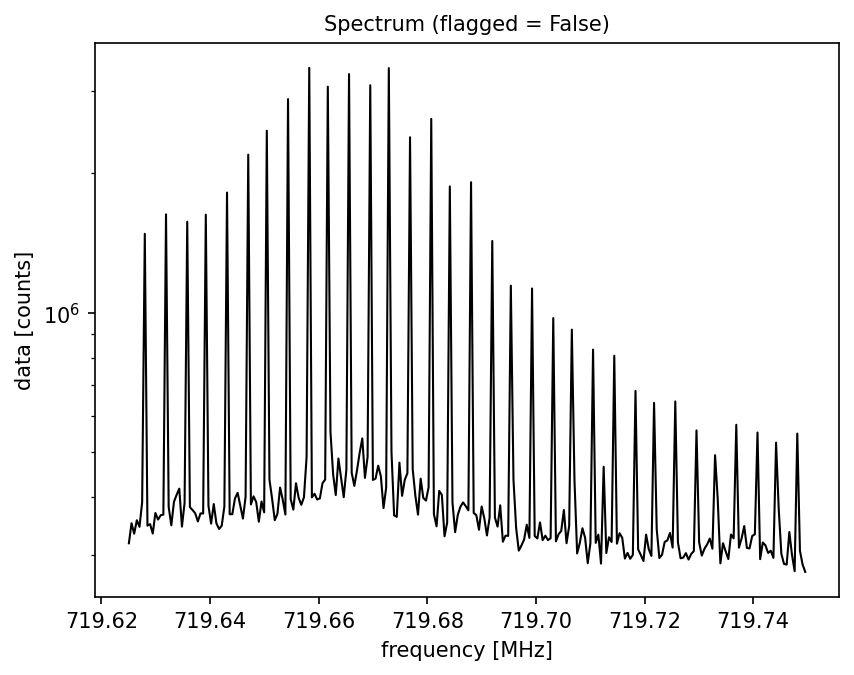

In [16]:
ax = sdhdf.plot_spectrum(
    beam=0, subband=0, x="frequency", flag=False, color="black", linewidth=1
)
ax.set_yscale("log")

#### A wide-band plot can be called from the `SDHDF` object, but it also really just calling down to the `Beam` class:

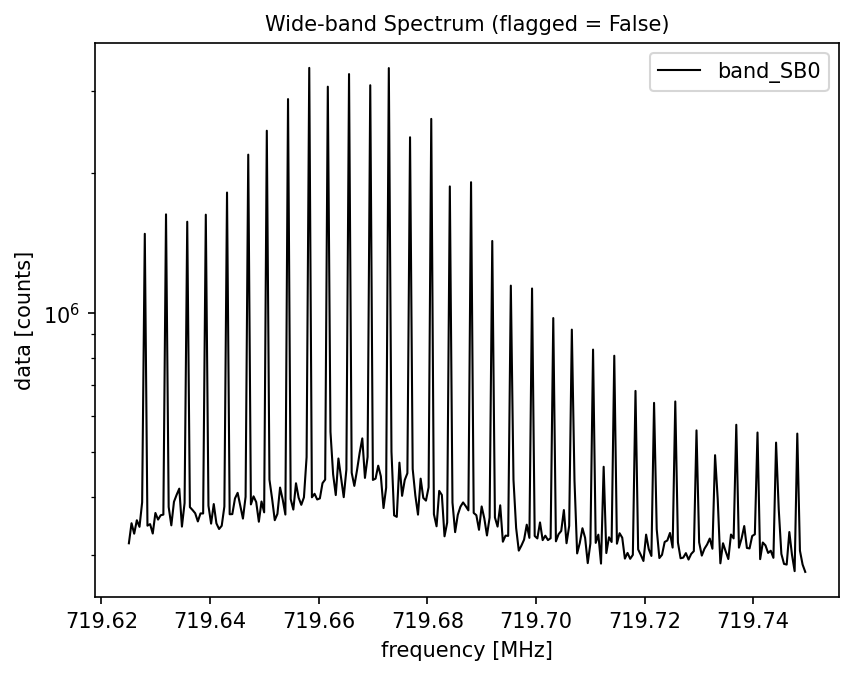

In [17]:
ax = sdhdf.plot_wide(
    beam=0, polarization=0, x="frequency", flag=False, color="black", linewidth=1
)
ax.set_yscale("log")

#### Now let's try and apply the RFI flagging routine:

In [18]:
sdhdf.auto_flag_rfi(sigma=5, n_windows=1, flag_persistent=False)

Flagging beams:   0%|          | 0/1 [00:00<?, ?it/s]

Flagging subbands:   0%|          | 0/1 [00:00<?, ?it/s]

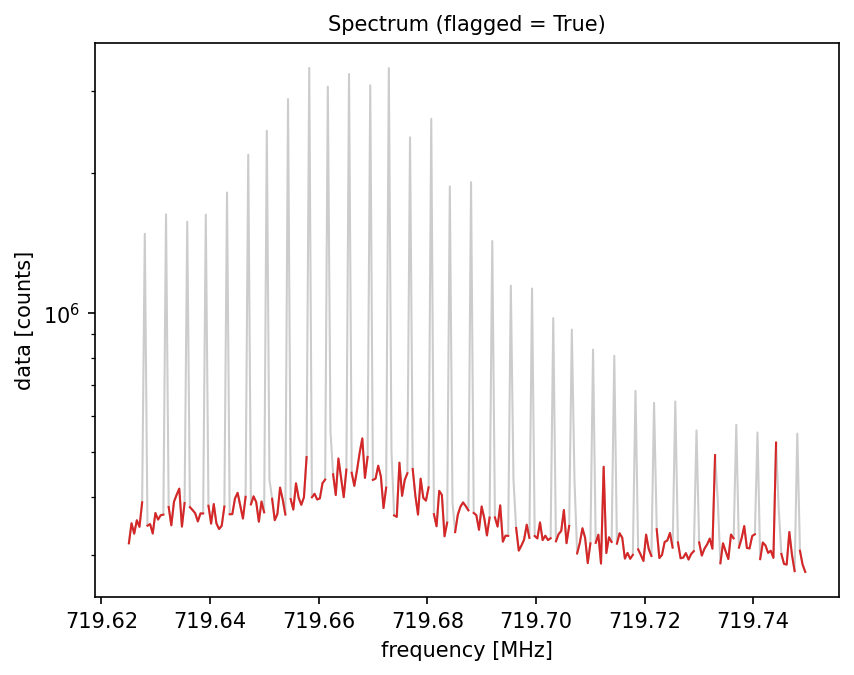

In [19]:
fig, ax = plt.subplots()
_ = sdhdf.plot_spectrum(
    beam=0,
    subband=0,
    polarization=0,
    x="frequency",
    flag=False,
    color="black",
    linewidth=1,
    alpha=0.2,
    ax=ax,
)
ax.set_yscale("log")

_ = sdhdf.plot_spectrum(
    beam=0,
    subband=0,
    polarization=0,
    x="frequency",
    flag=True,
    color="tab:red",
    linewidth=1,
    ax=ax,
)
ax.set_yscale("log")